In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('../data/uci-secom.csv')

In [6]:
df.shape

(1567, 592)

In [7]:
df["Pass/Fail"].value_counts()## 만약 데이터만 있다면 전 과정을 혼자 설계하고 진행할수 있을까

Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64

In [ ]:
missing_ratio = df.isna().mean() * 100         # 결과를 변수에 저장
missing_ratio[missing_ratio > 50] 
# shall 5

72     50.670070
73     50.670070
85     85.577537
109    64.964901
110    64.964901
111    64.964901
157    91.193363
158    91.193363
220    85.577537
244    64.964901
245    64.964901
246    64.964901
292    91.193363
293    91.193363
345    50.670070
346    50.670070
358    85.577537
382    64.964901
383    64.964901
384    64.964901
492    85.577537
516    64.964901
517    64.964901
518    64.964901
578    60.561583
579    60.561583
580    60.561583
581    60.561583
dtype: float64

In [56]:
high_missing_cols = missing_ratio[missing_ratio > 50].index
spec_cal_del = df.drop(columns = high_missing_cols)
print (df.shape)
print (spec_cal_del)
# shall 6

(1567, 592)
                     Time        0        1          2          3       4  \
0     2008-07-19 11:55:00  3030.93  2564.00  2187.7333  1411.1265  1.3602   
1     2008-07-19 12:32:00  3095.78  2465.14  2230.4222  1463.6606  0.8294   
2     2008-07-19 13:17:00  2932.61  2559.94  2186.4111  1698.0172  1.5102   
3     2008-07-19 14:43:00  2988.72  2479.90  2199.0333   909.7926  1.3204   
4     2008-07-19 15:22:00  3032.24  2502.87  2233.3667  1326.5200  1.5334   
...                   ...      ...      ...        ...        ...     ...   
1562  2008-10-16 15:13:00  2899.41  2464.36  2179.7333  3085.3781  1.4843   
1563  2008-10-16 20:49:00  3052.31  2522.55  2198.5667  1124.6595  0.8763   
1564  2008-10-17 05:26:00  2978.81  2379.78  2206.3000  1110.4967  0.8236   
1565  2008-10-17 06:01:00  2894.92  2532.01  2177.0333  1183.7287  1.5726   
1566  2008-10-17 06:07:00  2944.92  2450.76  2195.4444  2914.1792  1.5978   

          5         6       7       8  ...      577     582    

In [ ]:
df_clean = spec_cal_del.fillna(spec_cal_del.mean(numeric_only=True))
print (df_clean.shape)
print (df_clean.isna().sum().sum())
#shall 7

(1567, 564)
0


In [ ]:
import matplotlib.pyplot as plt 
plt.rc('font' , family = 'AppleGothic')
plt.rcParams["axes.unicode_minus"] = False
df_clean["Pass/Fail"].value_counts()


#shall_8

Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64

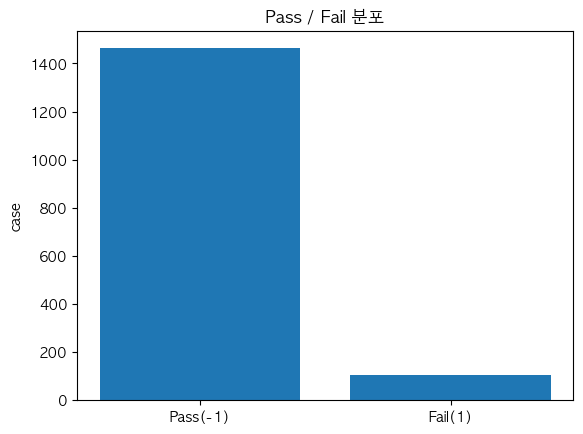

In [88]:
counts = df_clean["Pass/Fail"].value_counts()

plt.bar(["Pass(-1)", "Fail(1)"], counts.values)
plt.title("Pass / Fail 분포")
plt.ylabel("case")
plt.savefig("../outputs/shall10.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
from scipy import stats

pass_group = df_clean [df_clean["Pass/Fail"] == -1]
fail_group = df_clean [df_clean["Pass/Fail"] == 1]

In [ ]:
sensor_cols = [c for c in df_clean.columns if c not in ("Time", "Pass/Fail")]

results = []
for col in sensor_cols:
    t_stat, p_val = stats.ttest_ind(pass_group[col], fail_group[col],
                                     equal_var=False, nan_policy="omit")
    results.append({"sensor": col, "p_value": p_val})
#shall 12

/Users/minhyeok/Desktop/SECOM-Project/venv/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
ttest_df = pd.DataFrame(results).sort_values("p_value")
significant = ttest_df[ttest_df["p_value"] < 0.05]
print(len(significant))

79


In [ ]:
#오늘 할일 _과정은 본일을 하기위한 준비과정이다. 힘빼지 말고.
# AM : 영어 공부 루틴대로 각각 1시간 으로 타이머 끊기  
# AM(3) : 노션 (이력서 지원 가능 기업 리스트업 + 세부 사항 채워넣기)
# AM(2) : 대외활동(공모전) , 팀프로젝트 , 인턴쉽  리스트업 (1차AI_2차 수동)

In [ ]:
# PM : SECOM 종료 + 가능하다면 Githud 업로드  + 노션 작업물 텍스트화
# PM(2) : 


In [100]:
# shall 15 
top_sensor = significant["sensor"].head(15).tolist()

corr_matrix = df_clean[top_sensor].corr()

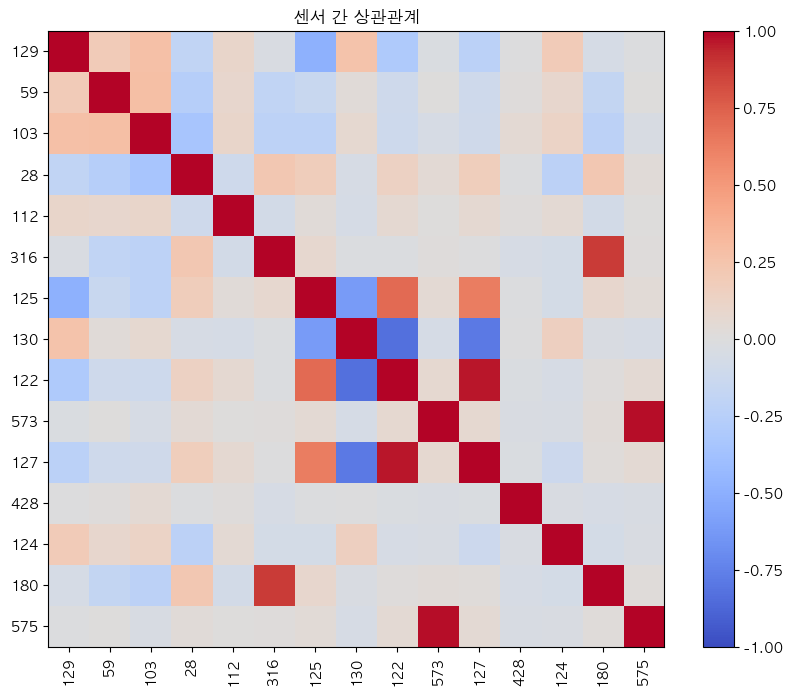

In [110]:
plt.figure(figsize=(10,8))
plt.imshow(corr_matrix, cmap="coolwarm",vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(top_sensor)),top_sensor, rotation=90)
plt.yticks(range(len(top_sensor)),top_sensor)
plt.title("센서 간 상관관계")
plt.savefig("../outputs/05_correlation_heatmap.png" , dpi=120, bbox_inches = "tight")
plt.show()

In [111]:
import numpy as np

mask = np.triu(np.ones(corr_matrix.shape), k = 1).astype(bool)
high_corr = corr_matrix.where(mask).stack()
high_corr = high_corr[high_corr.abs() > 0.8]
print(high_corr)

316  180    0.881081
130  122   -0.832151
122  127    0.962086
573  575    0.980265
dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

feature_cols = significant["sensor"].tolist()
X = df_clean[feature_cols]
Y = df_clean["Pass/Fail"]
# 셀 17 

In [115]:
X_train, X_test, Y_train,Y_test = train_test_split(X,Y,test_size=0.2, random_state=42, stratify=Y)
print(X_train.shape, X_test.shape)

(1253, 79) (314, 79)


In [116]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [117]:
model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train_scaled, Y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [118]:
y_pred = model.predict(X_test_scaled)
print(classification_report(Y_test, y_pred))
print(confusion_matrix(Y_test,y_pred))

              precision    recall  f1-score   support

          -1       0.95      0.80      0.87       293
           1       0.12      0.38      0.18        21

    accuracy                           0.77       314
   macro avg       0.53      0.59      0.52       314
weighted avg       0.89      0.77      0.82       314

[[234  59]
 [ 13   8]]


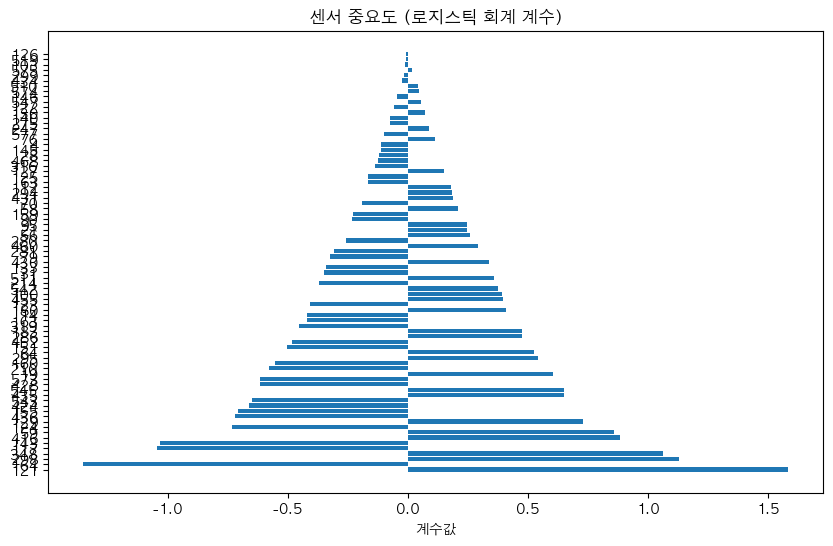

In [ ]:
coef_df = pd.DataFrame ({ 
    "sensor" : feature_cols,
    "coefficient" : model.coef_[0]
})
coef_df = coef_df.reindex(coef_df["coefficient"].abs().sort_values(ascending=False).index)

plt.figure(figsize=(10,6))
plt.barh(coef_df["sensor"], coef_df["coefficient"])
plt.title("센서 중요도 (로지스틱 회계 계수)")
plt.xlabel("계수값")
coef_df = coef_df.head(20)
plt.savefig("../outputs/07_feature_importance.png",dpi = 120, bbox_inches="tight")
plt.show()
